In [1]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,MessagesState
from typing import TypedDict,Annotated,Literal
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
#from pydirectoryloader import rag_function
import os 
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.utilities import GoogleSerperAPIWrapper,WikipediaAPIWrapper
import logging
from langchain.agents.middleware import before_model, after_model
from langchain.agents.middleware import SummarizationMiddleware
#from langchain.middleware.summarization import SummarizationMiddleware
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
#from langchain_anthropic.middleware import anthropicPromptCachingMiddleware
from langchain.agents.middleware import TodoListMiddleware
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
from langchain.agents import create_agent

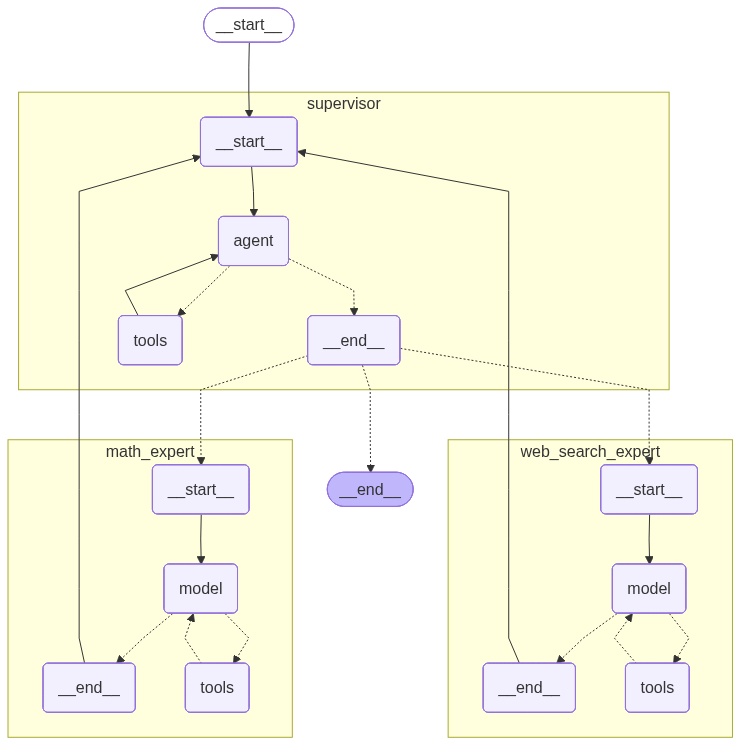

In [13]:
from langchain.chat_models import init_chat_model
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from IPython.display import Image, display

# Initialize the language model
llm = init_chat_model("openai:gpt-4o", temperature=0)

# Mathematical utility functions
def add(a: float, b: float) -> float:
    """Add two numbers.
    
    Args:
        a: First number to add
        b: Second number to add
        
    Returns:
        Sum of the two numbers
    """
    return a + b

def multiply(a: float, b: float) -> float:
    """Multiply two numbers.
    
    Args:
        a: First number to multiply
        b: Second number to multiply
        
    Returns:
        Product of the two numbers
    """
    return a * b

# Mock data retrieval function
def web_search(query: str) -> str:
    """Mock web search function that returns data from internet.
    
    Args:
        query: Search query string (unused in this mock implementation)
        
    Returns:
        Search results as a string
    """
    search_Tavily = TavilySearchResults(max_results=2)
    return search_Tavily.run(query)

# Improved agent prompts with clear role definitions and constraints
math_agent = create_agent(
    model=llm,
    tools=[add, multiply],
    name="math_expert",
    system_prompt="""You are a specialized mathematics expert with access to addition and multiplication tools.

Your responsibilities:
- Solve mathematical problems using the available tools
- Always use tools for calculations rather than computing mentally
- Use one tool at a time and show your work clearly
- Focus exclusively on mathematical computations

Constraints:
- Do NOT attempt research, web searches, or data gathering
- Do NOT perform calculations without using the provided tools
- Always explain your mathematical reasoning step by step"""
)

web_search_agent = create_agent(
    model=llm,
    tools=[web_search],
    name="web_search_expert",  
    system_prompt="""You are a specialized web search expert with access to internet search capabilities.

Your responsibilities:
- Find and retrieve factual information using web search
- Provide comprehensive, well-sourced answers to research questions
- Focus on data gathering and information synthesis

Constraints:
- Do NOT perform mathematical calculations or computations
- Do NOT attempt to solve math problems - delegate those to the math expert
- Always use your search tool to find current, accurate information
- Present findings clearly and cite sources when available"""
)

# Enhanced supervisor prompt with clear delegation strategy
supervisor_prompt = """You are an intelligent team supervisor managing two specialized experts: a research expert and a math expert.

Your role is to:
1. Analyze incoming requests to determine the required expertise
2. Delegate tasks to the appropriate specialist
3. Coordinate between agents when tasks require multiple skills
4. Synthesize results from multiple agents when necessary

Delegation Rules:
- For data gathering, company information, current events, or factual research → use research_agent
- For calculations, mathematical operations, or numerical analysis → use math_agent  
- For complex tasks requiring both research and math → delegate sequentially (research first, then math)

Important: You are a coordinator, not a doer. Always delegate work to your specialists rather than attempting tasks yourself. Never perform calculations or research directly."""

# Create supervisor workflow for coordinating agents
workflow = create_supervisor(
    [web_search_agent, math_agent],
    model=llm,
    prompt=supervisor_prompt
)

# Compile the multi-agent application
app = workflow.compile()
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [11]:

query = "what's are latest AI news and can you add 2 and 2 number , give me the result?"
result = app.invoke({"messages": [{"role": "user", "content": query}]})


In [12]:
for i in result['messages']:
    i.pretty_print()

================================ Human Message =================================

what's are latest AI news and can you add 2 and 2 number , give me the result?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_research_expert (call_smRu8mfPzQsF0rPDMhVnDJs2)
 Call ID: call_smRu8mfPzQsF0rPDMhVnDJs2
  Args:
================================= Tool Message =================================
Name: transfer_to_research_expert

Successfully transferred to research_expert
================================== Ai Message ==================================
Name: research_expert

### Latest AI News (October 2023)

1. **Canva's AI Tools**: Canva has introduced a suite of AI-powered design tools called Magic Studio. This includes features like Magic Switch, Magic Grab, Magic Expand, Magic Morph, Magic Alt Text, Magic Write, Magic Animate, and Translate, which help users edit images, produce videos, and use AI for copywriting and t